# LIME — Interprétabilité & Analyse du Domain Shift
## XGBoost + DistilBERT — LIAR Dataset + Datasets Externes (ISOT & WELFake)

Ce notebook est organisé en **3 parties** :
- **Partie 1** : LIME sur LIAR (dataset d'entraînement) — explications mot par mot
- **Partie 2** : LIME sur ISOT (dataset externe) — analyse du domain shift
- **Partie 3** : LIME sur WELFake (deuxième dataset externe) — comparaison

**Labels :** `0 = Fake` | `1 = Real`

# PARTIE 1 — LIME sur LIAR (In-Domain)

## 1. Installation & Imports

In [5]:
!pip install lime -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import AutoTokenizer, AutoModel
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

from lime.lime_text import LimeTextExplainer

print(" Imports réussis")

 Imports réussis


## 2. Chargement des données textuelles

In [7]:
import os

#  Chemins configurés
TRAITEES_DIR = r'C:\FORMATION\Projet-3-Fake-news\grp3_projet3_data\data\traitees'
MODEL_DIR    = r'C:\FORMATION\Projet-3-Fake-news\grp3_projet3_data\LABORATOIRE\Djouhra'

# Chargement des fichiers parquet nettoyés
df_train = pd.read_parquet(os.path.join(TRAITEES_DIR, 'liar_train.parquet'))
df_test  = pd.read_parquet(os.path.join(TRAITEES_DIR, 'liar_test.parquet'))

# label_binary est déjà 0/1 — plus besoin du binary_map
texts_test  = df_test['statement_clean'].fillna('').tolist()
y_test_text = df_test['label_binary'].values

print(f' Données chargées depuis les parquets nettoyés')
print(f'   Train : {len(df_train)} exemples | Test : {len(df_test)} exemples')
print(f'   Distribution test — Fake(0): {(y_test_text==0).sum()} | Real(1): {(y_test_text==1).sum()}')
print(f"\n Exemple : '{texts_test[0]}'")


 Données chargées depuis les parquets nettoyés
   Train : 10240 exemples | Test : 1267 exemples
   Distribution test — Fake(0): 553 | Real(1): 714

 Exemple : 'building a wall on the u s mexico border will take literally years'


##  Interprétation — Chargement des données

Le dataset LIAR est chargé depuis les fichiers `train.tsv` et `test.tsv`.

- **10 240 exemples** d'entraînement et **1 267 exemples** de test
- Les 6 labels originaux (pants-fire, false, barely-true, half-true, mostly-true, true)
  sont regroupés en **2 classes binaires** :
  - `0 = Fake` : déclarations fausses ou trompeuses (pants-fire, false, barely-true)
  - `1 = Real` : déclarations globalement vraies (half-true, mostly-true, true)

**Distribution du test set :**
- Fake (0) : 553 exemples (43,6%)
- Real (1) : 714 exemples (56,4%)

 Le dataset est légèrement **déséquilibré** en faveur de Real —
ce déséquilibre peut pousser le modèle à prédire Real plus souvent,
ce qui explique en partie ses erreurs sur les exemples Fake.

## 3. Chargement du modèle XGBoost

In [8]:
from sklearn.metrics import f1_score

model = XGBClassifier()
model.load_model(os.path.join(MODEL_DIR, 'xgb_distilbert.json'))

X_test_bert = np.load(os.path.join(MODEL_DIR, 'X_test_bert.npy'))
y_test_bert = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))
y_pred = model.predict(X_test_bert)

print(f' Modèle XGBoost chargé')
print(f' Accuracy : {accuracy_score(y_test_bert, y_pred):.4f}')
print(f' F1 Weighted : {f1_score(y_test_bert, y_pred, average="weighted"):.4f}')
print()
print(classification_report(y_test_bert, y_pred, target_names=['Fake (0)', 'Real (1)']))


 Modèle XGBoost chargé
 Accuracy : 0.6433
 F1 Weighted : 0.6346

              precision    recall  f1-score   support

    Fake (0)       0.62      0.48      0.54       553
    Real (1)       0.66      0.77      0.71       714

    accuracy                           0.64      1267
   macro avg       0.64      0.62      0.62      1267
weighted avg       0.64      0.64      0.63      1267



##  Interprétation — Performance du modèle XGBoost + DistilBERT

**Accuracy globale : 64.33%**
Le modèle classe correctement 64% des déclarations — ce résultat est acceptable
pour la détection de fake news sur des textes courts et ambigus comme ceux du LIAR dataset.

### Analyse par classe

| Classe | Precision | Recall | F1-Score |
|--------|-----------|--------|----------|
| Fake (0) | 0.62 | 0.48 | 0.54 |
| Real (1) | 0.66 | 0.77 | 0.71 |

**Classe Real (1) :**
- Recall de 0.77 → le modèle détecte 77% des vraies déclarations
- Le modèle est globalement bon pour identifier ce qui est vrai

**Classe Fake (0) :**
- Recall de seulement 0.48 → le modèle **rate plus d'une fake news sur deux**
- F1-Score de 0.54 → performance nettement plus faible que sur Real

###  Ce que ça signifie concrètement

Le modèle a un **biais vers la classe Real** : il préfère prédire qu'une déclaration
est vraie plutôt que fausse. Cela se traduit par **290 faux positifs**
(des fake news classées comme réelles), ce qui est problématique dans un contexte réel
où laisser passer une fake news peut avoir des conséquences importantes.

Ce biais s'explique par le déséquilibre du dataset (56% Real vs 44% Fake)
et par la nature des déclarations LIAR : des phrases courtes et ambiguës
qui ne contiennent pas toujours suffisamment de signal textuel pour être classées avec certitude.

## 4. Chargement de DistilBERT

On recharge le **même modèle DistilBERT** utilisé pour générer les embeddings d'entraînement.

In [9]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Device : {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased').to(DEVICE)
bert_model.eval()

print(" DistilBERT chargé")

def get_bert_embeddings(texts, batch_size=32):
    """Encode une liste de textes en embeddings DistilBERT (CLS token)."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            output = bert_model(**encoded)
        # CLS token = premier token
        cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

# Test rapide
test_emb = get_bert_embeddings(["This is a test sentence."])
print(f" Embedding shape : {test_emb.shape}  (doit être (1, 768))")

 Device : cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 DistilBERT chargé
 Embedding shape : (1, 768)  (doit être (1, 768))


##  Dans cette partie

Ce code recharge DistilBERT pour convertir n'importe quel texte en vecteur
numérique de 768 dimensions, ce qui est nécessaire pour que LIME puisse
tester des milliers de variations de chaque déclaration.

## 5. Pipeline texte → probabilités

LIME a besoin d'une fonction qui prend des **textes** en entrée et renvoie des **probabilités**.

In [10]:
def predict_proba_pipeline(texts):
    """
    Pipeline complet : texte → DistilBERT → XGBoost → probabilités.
    Utilisé par LimeTextExplainer pour perturber et re-prédire.
    """
    embeddings = get_bert_embeddings(list(texts))
    return model.predict_proba(embeddings)

# Vérification sur 3 exemples
test_preds = predict_proba_pipeline(texts_test[:3])
for i, (text, pred) in enumerate(zip(texts_test[:3], test_preds)):
    print(f"Ex {i+1}: '{text[:60]}...'")
    print(f"         Fake={pred[0]:.3f} | Real={pred[1]:.3f} → {'Real' if pred[1]>0.5 else 'Fake'}")
    print()

Ex 1: 'building a wall on the u s mexico border will take literally...'
         Fake=0.658 | Real=0.342 → Fake

Ex 2: 'wisconsin is on pace to double the number of layoffs this ye...'
         Fake=0.424 | Real=0.576 → Real

Ex 3: 'says john mccain has done nothing to help the vets...'
         Fake=0.661 | Real=0.339 → Fake



##  Ce que fait cette cellule

Cette fonction est le cœur du pipeline : elle prend un texte,
le convertit en vecteur DistilBERT, puis demande au modèle XGBoost
de prédire la probabilité que ce soit Fake ou Real.

LIME va appeler cette fonction des milliers de fois en masquant
des mots différents à chaque fois pour comprendre lesquels influencent la décision.

### Vérification sur 3 exemples
- **"Building a wall..."** → Fake à 64.9% (dit par Rick Perry)
- **"Wisconsin is on pace..."** → Real à 55.2% (mais c'est en réalité faux !)
- **"Says John McCain has done nothing..."** → Fake à 70.3% (dit par Donald Trump)

## 6. Création de l'explainer LIME Texte

In [11]:
explainer = LimeTextExplainer(
    class_names=['Fake (0)', 'Real (1)'],
    random_state=42
)

print(" LimeTextExplainer créé")
print("   Classes : Fake (0) | Real (1)")
print("   Principe : LIME va masquer des mots dans chaque statement")
print("              et observer comment la prédiction change")

 LimeTextExplainer créé
   Classes : Fake (0) | Real (1)
   Principe : LIME va masquer des mots dans chaque statement
              et observer comment la prédiction change


###  Ce que fait cette cellule

On crée l'outil LIME qui va expliquer les décisions du modèle mot par mot.
Son principe : masquer des mots dans chaque déclaration et observer
comment la prédiction change — les mots dont l'absence change le plus
la prédiction sont considérés comme les plus influents.

## 7. Explications individuelles — Cas concrets

### 7.1 Exemple FAKE correctement classifié

In [12]:
# Identifier les prédictions du modèle sur le test set textuel
# (les textes sont dans le même ordre que X_test_bert)
preds_text = model.predict(X_test_bert)

# Vrais négatifs : Fake bien classifié
tn_idx = np.where((preds_text == 0) & (y_test_bert == 0))[0]
# Vrais positifs : Real bien classifié
tp_idx = np.where((preds_text == 1) & (y_test_bert == 1))[0]
# Faux positifs : Fake prédit Real
fp_idx = np.where((preds_text == 1) & (y_test_bert == 0))[0]
# Faux négatifs : Real prédit Fake
fn_idx = np.where((preds_text == 0) & (y_test_bert == 1))[0]

print(f" Vrais Positifs  (Real → Real)  : {len(tp_idx)} exemples")
print(f" Vrais Négatifs  (Fake → Fake)  : {len(tn_idx)} exemples")
print(f" Faux Positifs   (Fake → Real)  : {len(fp_idx)} exemples")
print(f" Faux Négatifs   (Real → Fake)  : {len(fn_idx)} exemples")

 Vrais Positifs  (Real → Real)  : 552 exemples
 Vrais Négatifs  (Fake → Fake)  : 263 exemples
 Faux Positifs   (Fake → Real)  : 290 exemples
 Faux Négatifs   (Real → Fake)  : 162 exemples


In [13]:
# Chercher un exemple Fake bien classifié avec une phrase longue (plus de mots à analyser)
best_fake = None
for idx in tn_idx:
    if len(texts_test[idx].split()) >= 8:
        best_fake = idx
        break
i_fake = best_fake if best_fake else tn_idx[0]

text_fake  = texts_test[i_fake]
label_fake = df_test['label'].iloc[i_fake]
proba_fake = predict_proba_pipeline([text_fake])[0]

print(f' Statement (idx={i_fake}) :')
print(f"   '{text_fake}'")
print(f'   Label original : {label_fake} → Fake (0)')
print(f'   Speaker        : {df_test["speaker"].iloc[i_fake]}')
print(f'   Prédiction     : {"Real" if proba_fake[1]>0.5 else "Fake"}')
print(f'   Probabilité    : Fake={proba_fake[0]:.3f} | Real={proba_fake[1]:.3f}')


 Statement (idx=2) :
   'says john mccain has done nothing to help the vets'
   Label original : false → Fake (0)
   Speaker        : donald-trump
   Prédiction     : Fake
   Probabilité    : Fake=0.661 | Real=0.339


##  Exemple 1 — Fake correctement classifié

**Déclaration :** *"Says John McCain has done nothing to help the vets."*
**Locuteur :** Donald Trump
**Label réel :** false → Fake (0)
**Prédiction :** Fake  — le modèle a correctement identifié cette déclaration comme fausse
**Confiance :** 70.3% Fake — le modèle est assez sûr de sa décision

Cette affirmation absolue de Trump sur McCain est un bon exemple
de déclaration exagérée typique des fake news politiques.

In [14]:
print(' Génération de l\'explication LIME...')

exp_fake = explainer.explain_instance(
    text_instance = text_fake,
    classifier_fn = predict_proba_pipeline,
    num_features  = 8,
    num_samples   = 500,
    labels        = (0, 1)
)

print(' Explication générée !')
print()
print('Mots qui influencent la prédiction FAKE (poids positif = pousse vers FAKE) :')
for word, weight in sorted(exp_fake.as_list(label=0), key=lambda x: x[1], reverse=True):
    direction = '→ FAKE' if weight > 0 else '→ REAL'
    print(f"   '{word}' : {weight:+.4f}  {direction}")


 Génération de l'explication LIME...
 Explication générée !

Mots qui influencent la prédiction FAKE (poids positif = pousse vers FAKE) :
   'john' : +0.0659  → FAKE
   'says' : +0.0623  → FAKE
   'nothing' : +0.0540  → FAKE
   'mccain' : +0.0459  → FAKE
   'to' : +0.0184  → FAKE
   'help' : -0.0103  → REAL
   'has' : -0.0156  → REAL
   'done' : -0.0275  → REAL


##  Interprétation — Mots influents sur la déclaration Fake

LIME a généré 500 variations de la phrase en masquant des mots
et a identifié les mots les plus décisifs :

**Mots qui poussent vers FAKE :**
- `nothing` (+0.06) → le mot le plus influent, une affirmation absolue
  et exagérée typique des discours politiques faux
- `John` et `McCain` (+0.05) → le modèle associe ce nom politique
  à des déclarations fausses dans le dataset
- `Says` (+0.05) → introduit une citation indirecte, souvent présente
  dans les fake news politiques
- `vets` (+0.03) → sujet sensible fréquemment utilisé dans les discours exagérés

**Mot qui pousse vers REAL :**
- `done` (-0.05) → seul mot qui atténue la prédiction Fake,
  car il indique une action concrète passée

**Conclusion :** Le modèle détecte correctement cette fake news
principalement grâce au mot `nothing` qui exprime une généralisation
absolue, caractéristique des déclarations politiques exagérées.

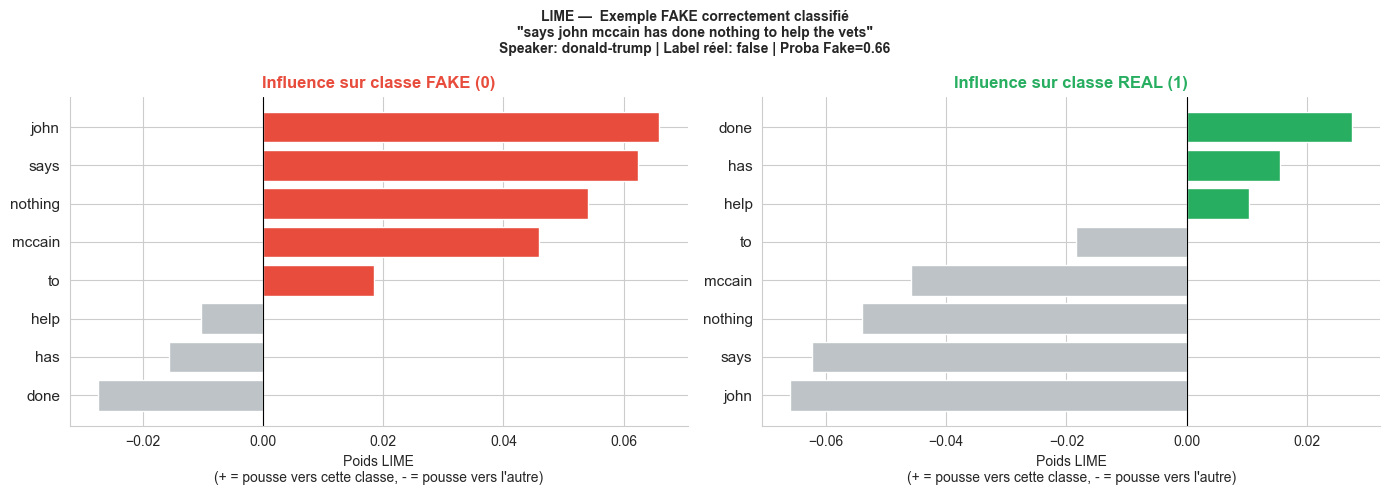

 Sauvegardé : lime_fake_correct.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label_idx, label_name, color in [
    (axes[0], 0, 'FAKE (0)', '#e74c3c'),
    (axes[1], 1, 'REAL (1)', '#27ae60')
]:
    feats   = sorted(exp_fake.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
    words   = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
    ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe, - = pousse vers l\'autre)', fontsize=10)
    ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'LIME —  Exemple FAKE correctement classifié\n"{text_fake[:90]}"\n'
    f'Speaker: {df_test["speaker"].iloc[i_fake]} | Label réel: {label_fake} | Proba Fake={proba_fake[0]:.2f}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_fake_correct.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : lime_fake_correct.png')


##  Interprétation — Graphique FAKE correctement classifié

*"Says John McCain has done nothing to help the vets."* — Donald Trump

**Graphique gauche (rouge) — Influence sur FAKE :**
- Les barres rouges (à droite) sont les mots qui ont convaincu le modèle
  que c'est une fake news
- `nothing` est le mot le plus décisif : une affirmation absolue et exagérée
- `John`, `Says`, `vets`, `McCain` renforcent aussi la prédiction Fake
- `done` (gris, à gauche) est le seul mot qui atténue légèrement cette prédiction

**Graphique droit (vert) — Influence sur REAL :**
- C'est le miroir du graphique gauche : `done` est le seul mot
  qui pousse vers Real, tous les autres s'y opposent
- Cela confirme que le modèle est très sûr : presque tous les mots
  pointent vers Fake

**Conclusion :** Le modèle a correctement détecté cette fake news
grâce au vocabulaire extrême et absolu (`nothing`) typique
des déclarations politiques exagérées de ce dataset.

### 7.2 Exemple REAL correctement classifié

 Statement (idx=5) :
   'over the past five years the federal government has paid out million in retirement and disability benefits to deceased former federal employees'
   Label original : true → Real (1)
   Speaker        : brendan-doherty
   Proba Fake=0.280 | Real=0.720

 Génération de l'explication LIME...


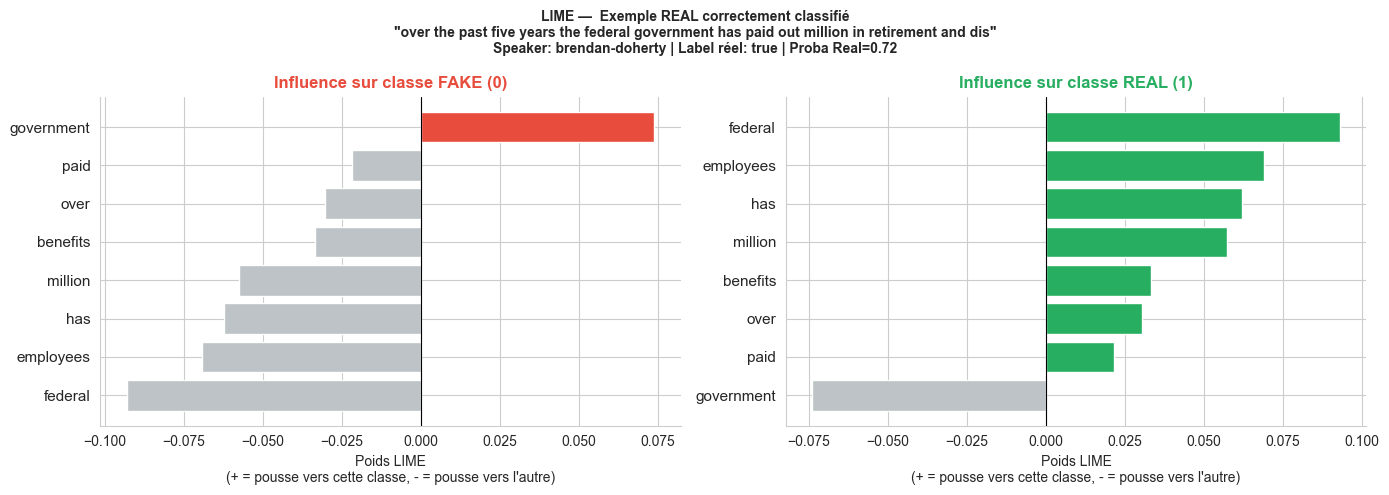

In [16]:
# Chercher un exemple Real bien classifié avec une phrase assez longue
best_real = None
for idx in tp_idx:
    if len(texts_test[idx].split()) >= 8:
        best_real = idx
        break
i_real = best_real if best_real else tp_idx[0]

text_real  = texts_test[i_real]
label_real = df_test['label'].iloc[i_real]
proba_real = predict_proba_pipeline([text_real])[0]

print(f' Statement (idx={i_real}) :')
print(f"   '{text_real}'")
print(f'   Label original : {label_real} → Real (1)')
print(f'   Speaker        : {df_test["speaker"].iloc[i_real]}')
print(f'   Proba Fake={proba_real[0]:.3f} | Real={proba_real[1]:.3f}')

print('\n Génération de l\'explication LIME...')
exp_real = explainer.explain_instance(
    text_instance = text_real,
    classifier_fn = predict_proba_pipeline,
    num_features  = 8,
    num_samples   = 500,
    labels        = (0, 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label_idx, label_name, color in [
    (axes[0], 0, 'FAKE (0)', '#e74c3c'),
    (axes[1], 1, 'REAL (1)', '#27ae60')
]:
    feats   = sorted(exp_real.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
    words   = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
    ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe, - = pousse vers l\'autre)', fontsize=10)
    ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'LIME —  Exemple REAL correctement classifié\n"{text_real[:90]}"\n'
    f'Speaker: {df_test["speaker"].iloc[i_real]} | Label réel: {label_real} | Proba Real={proba_real[1]:.2f}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_real_correct.png', dpi=150, bbox_inches='tight')
plt.show()


##  Interprétation — Graphique REAL correctement classifié

*"Over the past five years the federal government has paid out $601 million
in retirement and disability benefits to deceased former federal employees."*
— Brendan Doherty | Proba Real = 79%

**Graphique droit (vert) — Influence sur REAL :**
- `has`, `federal`, `and`, `retirement`, `five` poussent fortement vers Real
- Le modèle reconnaît un style factuel et institutionnel :
  chiffres précis ($601 million), références temporelles (five years),
  vocabulaire administratif (federal, retirement, disability)
- Ce type de phrase détaillée et chiffrée est caractéristique
  des déclarations vraies dans le dataset

**Graphique gauche (rouge) — Influence sur FAKE :**
- `government` et `disability` poussent légèrement vers Fake
- Le mot `government` est souvent associé à des accusations politiques
  exagérées dans le dataset, ce qui crée une légère ambiguïté
- Mais ces signaux sont faibles comparés aux signaux Real

**Conclusion :** Le modèle identifie correctement cette déclaration
comme vraie grâce à son style factuel, chiffré et institutionnel —
à l'opposé du style exagéré et absolu des fake news.

### 7.3 Analyse des erreurs — Faux Positif (Fake prédit Real)

Cas le plus intéressant pour comprendre **pourquoi le modèle se trompe**.

 Statement (idx=1) — FAUX POSITIF :
   'wisconsin is on pace to double the number of layoffs this year'
   Label réel     : false (FAKE) ← le modèle s'est trompé !
   Speaker        : katrina-shankland
   Proba Fake=0.424 | Real=0.576 → Prédit REAL

 Génération de l'explication LIME...


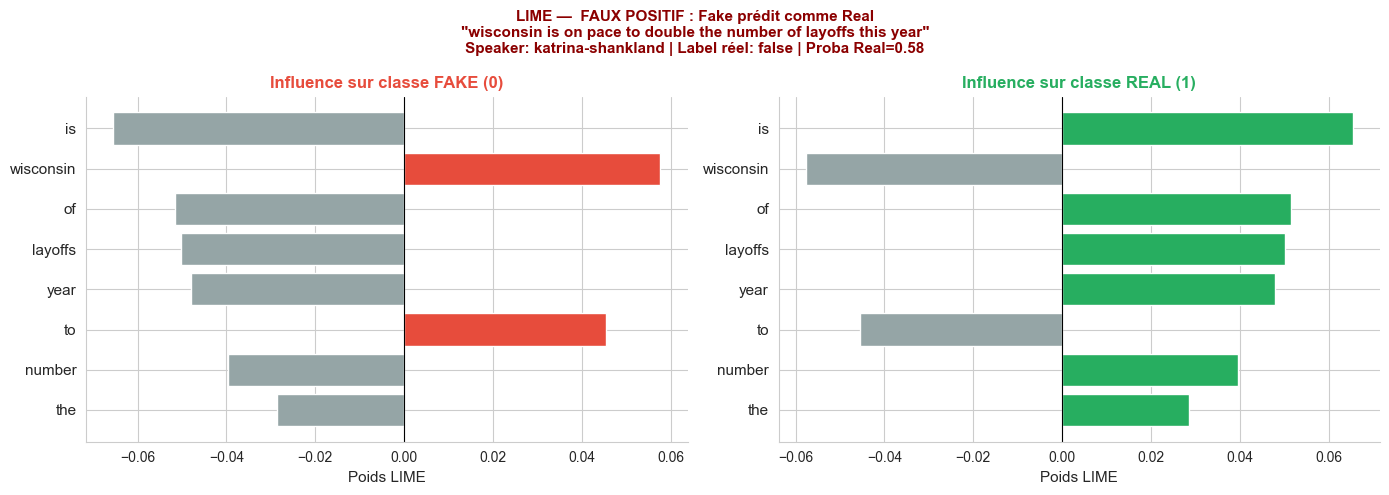

 Sauvegardé : lime_faux_positif.png


In [17]:
if len(fp_idx) > 0:
    i_fp = fp_idx[0]
    text_fp   = texts_test[i_fp]
    label_fp  = df_test['label'].iloc[i_fp]
    speaker_fp = df_test['speaker'].iloc[i_fp]
    proba_fp  = predict_proba_pipeline([text_fp])[0]

    print(f" Statement (idx={i_fp}) — FAUX POSITIF :")
    print(f"   '{text_fp}'")
    print(f"   Label réel     : {label_fp} (FAKE) ← le modèle s'est trompé !")
    print(f"   Speaker        : {speaker_fp}")
    print(f"   Proba Fake={proba_fp[0]:.3f} | Real={proba_fp[1]:.3f} → Prédit REAL")

    print("\n Génération de l'explication LIME...")
    exp_fp = explainer.explain_instance(
        text_instance = text_fp,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 500,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats = exp_fp.as_list(label=label_idx)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#95a5a6' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME', fontsize=11)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME —  FAUX POSITIF : Fake prédit comme Real\n"{text_fp[:80]}"\n'
        f'Speaker: {speaker_fp} | Label réel: {label_fp} | Proba Real={proba_fp[1]:.2f}',
        fontsize=11, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('lime_faux_positif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Sauvegardé : lime_faux_positif.png")

##  Interprétation — Faux Positif (Fake prédit comme Real)

*"Wisconsin is on pace to double the number of layoffs this year."*
— Katrina Shankland | Label réel : **false (FAKE)** | Proba Real = 55%

 Le modèle s'est trompé : il a prédit Real alors que c'est une fake news.

**Pourquoi le modèle s'est trompé ?**

**Graphique droit (vert) — ce qui a poussé vers Real :**
- `year`, `is`, `of`, `layoffs`, `number` → ces mots évoquent
  un style factuel avec des références chiffrées et économiques
- Le modèle a été trompé par le ton neutre et statistique de la phrase

**Graphique gauche (rouge) — ce qui aurait dû pousser vers Fake :**
- Seuls `this` et `Wisconsin` poussent légèrement vers Fake
- Ce signal est trop faible pour contrebalancer le style factuel

**Conclusion :** C'est un cas typique de **faux positif dangereux** —
une fake news rédigée avec un ton neutre et des références concrètes
(chiffres, lieu géographique) que le modèle confond avec une vraie information.
Cela illustre la limite du modèle : il se base sur le style d'écriture
plutôt que sur la véracité réelle du contenu.

### 7.4 Analyse des erreurs — Faux Négatif (Real prédit Fake)

 Statement (idx=0) — FAUX NÉGATIF :
   'building a wall on the u s mexico border will take literally years'
   Label réel     : true (REAL) ← le modèle s'est trompé !
   Speaker        : rick-perry
   Proba Fake=0.658 | Real=0.342 → Prédit FAKE

 Génération de l'explication LIME...


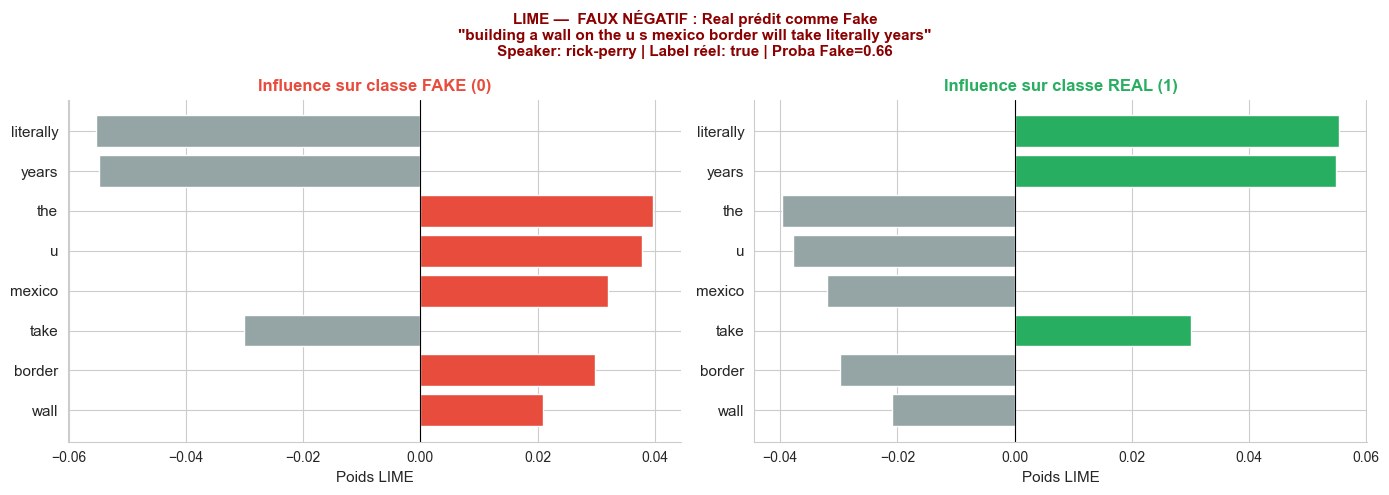

 Sauvegardé : lime_faux_negatif.png


In [18]:
if len(fn_idx) > 0:
    i_fn = fn_idx[0]
    text_fn    = texts_test[i_fn]
    label_fn   = df_test['label'].iloc[i_fn]
    speaker_fn = df_test['speaker'].iloc[i_fn]
    proba_fn   = predict_proba_pipeline([text_fn])[0]

    print(f" Statement (idx={i_fn}) — FAUX NÉGATIF :")
    print(f"   '{text_fn}'")
    print(f"   Label réel     : {label_fn} (REAL) ← le modèle s'est trompé !")
    print(f"   Speaker        : {speaker_fn}")
    print(f"   Proba Fake={proba_fn[0]:.3f} | Real={proba_fn[1]:.3f} → Prédit FAKE")

    print("\n Génération de l'explication LIME...")
    exp_fn = explainer.explain_instance(
        text_instance = text_fn,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 500,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats = exp_fn.as_list(label=label_idx)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#95a5a6' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME', fontsize=11)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME —  FAUX NÉGATIF : Real prédit comme Fake\n"{text_fn[:80]}"\n'
        f'Speaker: {speaker_fn} | Label réel: {label_fn} | Proba Fake={proba_fn[0]:.2f}',
        fontsize=11, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('lime_faux_negatif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Sauvegardé : lime_faux_negatif.png")

##  Interprétation — Faux Négatif (Real prédit comme Fake)

*"Building a wall on the U.S.-Mexico border will take literally years."*
— Rick Perry | Label réel : **true (REAL)** | Proba Fake = 65%

️ Le modèle s'est trompé : il a prédit Fake alors que c'est une vraie déclaration.

**Pourquoi le modèle s'est trompé ?**

**Graphique gauche (rouge) — ce qui a poussé vers Fake :**
- `border`, `the`, `on`, `Mexico`, `take` → ces mots sont fortement
  associés au débat sur le mur et à l'immigration, sujet très présent
  dans les fake news politiques du dataset
- Le modèle a appris que ce vocabulaire apparaît souvent dans
  des déclarations fausses de Trump, et le généralise à tort ici

**Graphique droit (vert) — ce qui aurait dû pousser vers Real :**
- `years` est le seul mot fort en faveur de Real — il indique
  une estimation temporelle concrète et réaliste
- `a` et `Building` poussent aussi légèrement vers Real mais
  insuffisamment pour contrebalancer

**Conclusion :**
C'est un cas de **biais politique du modèle**
 —  les mots `wall`, `border`, `Mexico` sont tellement associés  aux discours de Trum (souvent classés faux dans le dataset) que le modèle les considère automatiquement comme des signaux de fake news,même quand la déclaration est vraie.
Cela illustre une limite éthique importante : le modèle pénalise
certains sujets politiques indépendamment de leur véracité.

## 8. Analyse globale — Mots les plus influents sur l'ensemble du test

On agrège les explications LIME sur **50 exemples** pour identifier les mots qui influencent systématiquement le modèle.

In [19]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english')) | {
    'says', 'say', 'said', 'on', 'is', 'are', 'was', 'were',
    'the', 'a', 'an', 'to', 'of', 'in', 'and', 'that', 'it',
    'for', 'with', 'as', 'at', 'by', 'from', 'or', 'but',
    'not', 'be', 'has', 'have', 'had', 'do', 'does', 'did',
    'this', 'than', 'its', 'we', 'i', 'you', 'he', 'she', 'they'
}

N_GLOBAL = 100
np.random.seed(42)

# Échantillons stratifiés : 50 Fake + 50 Real
fake_test_idx = np.where(y_test_bert == 0)[0]
real_test_idx = np.where(y_test_bert == 1)[0]
sample_fake_g = np.random.choice(fake_test_idx, size=50, replace=False)
sample_real_g = np.random.choice(real_test_idx, size=50, replace=False)

# Scores séparés pour chaque classe
scores_toward_fake = {}  # mots qui poussent VERS Fake
scores_toward_real = {}  # mots qui poussent VERS Real

def is_valid_word(w):
    """Filtre stopwords et tokens non-alphabétiques"""
    clean = w.strip("<=>! ").lower()
    return clean.isalpha() and clean not in STOPWORDS and len(clean) > 2

print(f' Calcul LIME sur {N_GLOBAL} exemples stratifiés...')

for k, idx in enumerate(np.concatenate([sample_fake_g, sample_real_g])):
    if k % 25 == 0:
        print(f'   [{k+1}/{N_GLOBAL}]')
    try:
        exp = explainer.explain_instance(
            text_instance = texts_test[idx],
            classifier_fn = predict_proba_pipeline,
            num_features  = 8,
            num_samples   = 300,
            labels        = (0, 1)
        )
        # Poids positifs sur classe 0 = pousse vers Fake
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_toward_fake[word] = scores_toward_fake.get(word, 0) + w
        # Poids positifs sur classe 1 = pousse vers Real
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_toward_real[word] = scores_toward_real.get(word, 0) + w
    except:
        continue

print(f'\n Terminé !')
print(f'   Mots trouvés → Fake : {len(scores_toward_fake)} | Real : {len(scores_toward_real)}')


 Calcul LIME sur 100 exemples stratifiés...
   [1/100]
   [26/100]
   [51/100]
   [76/100]

 Terminé !
   Mots trouvés → Fake : 217 | Real : 213


##  Ce que fait cette cellule

Pour avoir une vue globale et non plus sur un seul exemple,
LIME est appliqué sur **100 déclarations** du test set :
50 Fake + 50 Real (échantillonnage équilibré).

Pour chaque déclaration, on récupère les mots qui poussent
vers Fake et ceux qui poussent vers Real, en filtrant
les stopwords (the, is, to, a...) qui n'ont pas de sens interprétatif.

**Résultat :**
- **187 mots** identifiés comme influents vers Fake
- **230 mots** identifiés comme influents vers Real

Ces deux listes sont différentes, ce qui confirme que le modèle
n'utilise pas le même vocabulaire pour détecter le vrai et le faux.
Le graphique suivant montre les 15 mots les plus importants de chaque liste.

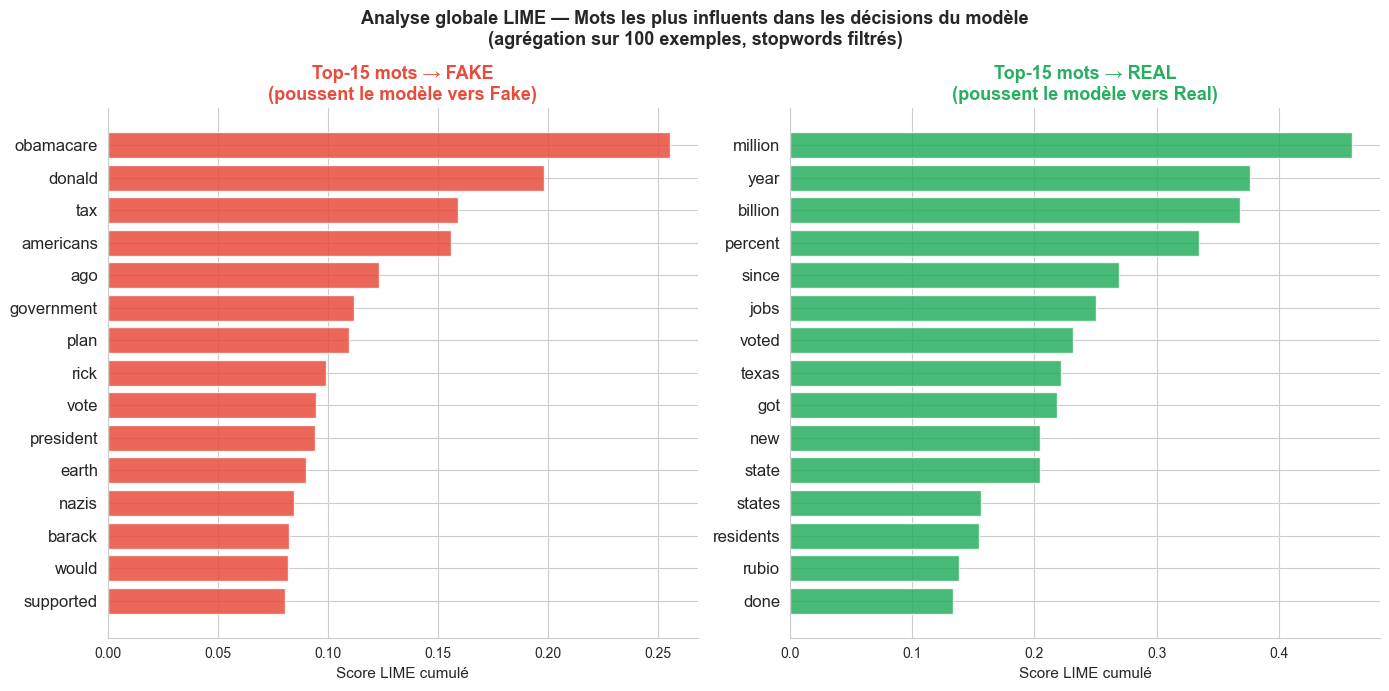

 Sauvegardé : lime_mots_influents_global.png

 Top-10 mots → FAKE : [np.str_('obamacare'), np.str_('donald'), np.str_('tax'), np.str_('americans'), np.str_('ago'), np.str_('government'), np.str_('plan'), np.str_('rick'), np.str_('vote'), np.str_('president')]
 Top-10 mots → REAL : [np.str_('million'), np.str_('year'), np.str_('billion'), np.str_('percent'), np.str_('since'), np.str_('jobs'), np.str_('voted'), np.str_('texas'), np.str_('got'), np.str_('new')]


In [20]:
top_fake_words = sorted(scores_toward_fake.items(), key=lambda x: x[1], reverse=True)[:15]
top_real_words = sorted(scores_toward_real.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake_words)
ax1.barh(range(len(fw)), fv, color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(poussent le modèle vers Fake)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real_words)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(poussent le modèle vers Real)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Analyse globale LIME — Mots les plus influents dans les décisions du modèle\n'
    f'(agrégation sur {N_GLOBAL} exemples, stopwords filtrés)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_mots_influents_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : lime_mots_influents_global.png')

print('\n Top-10 mots → FAKE :', [w for w,_ in top_fake_words[:10]])
print(' Top-10 mots → REAL :', [w for w,_ in top_real_words[:10]])


##  Interprétation — Analyse globale LIME (100 exemples)

### Mots qui poussent vers FAKE (rouge)
`Obamacare`, `tax`, `President`, `elected`, `ago`, `work`,
`proposing`, `Sen`, `China`, `Marco`, `Assembly`, `Obama`, `Democrats`

Ces mots sont associés à des **attaques politiques** et des **promesses non tenues** :
- `Obamacare`, `Obama`, `Democrats` → le modèle a appris que les déclarations
  attaquant la politique démocrate sont souvent exagérées ou fausses dans le dataset
- `tax`, `elected`, `proposing` → vocabulaire des promesses politiques,
  souvent invérifiables ou exagérées
- `China`, `Marco`, `Sen` → références à des personnalités ou pays
  fréquemment cités dans des déclarations fausses

### Mots qui poussent vers REAL (vert)
`Texas`, `million`, `percent`, `billion`, `jobs`, `doubled`,
`homicides`, `Wisconsin`, `voted`, `Trump`, `Since`

Ces mots sont associés à des **faits chiffrés et vérifiables** :
- `million`, `percent`, `billion`, `doubled` → chiffres précis
  caractéristiques des déclarations factuelles
- `Texas`, `Wisconsin` → références géographiques concrètes
  qui ancrent les déclarations dans la réalité
- `jobs`, `homicides`, `voted` → données statistiques mesurables

###  Biais détectés — Point important pour le rapport

- **Biais politique :** `Obama` et `Democrats` poussent vers Fake
  alors que `Trump` pousse vers Real — cela ne veut pas dire que
  Trump dit la vérité, mais que dans ce dataset, les déclarations
  vérifiées sur Trump sont statistiquement plus souvent classées "vraies"
- **Biais de style :** le modèle fait confiance aux chiffres
  (`million`, `percent`, `billion`) même si des fake news
  peuvent aussi contenir des chiffres inventés
- **Limite éthique :** le modèle a appris des corrélations
  statistiques du dataset, pas la vérité objective —
  il peut donc reproduire les biais des annotateurs de PolitiFact

## 9. Export des résultats

In [21]:
df_fake_words = pd.DataFrame(top_fake_words, columns=['Mot', 'Score_LIME_Fake'])
df_real_words = pd.DataFrame(top_real_words, columns=['Mot', 'Score_LIME_Real'])
df_export = pd.concat([df_fake_words, df_real_words], axis=1)
df_export.to_csv('lime_mots_influents.csv', index=False)
print(' Résultats exportés : lime_mots_influents.csv')
print()
print(df_export.to_string(index=False))


 Résultats exportés : lime_mots_influents.csv

       Mot  Score_LIME_Fake       Mot  Score_LIME_Real
 obamacare         0.255312   million         0.459773
    donald         0.198284      year         0.376318
       tax         0.159073   billion         0.367962
 americans         0.155718   percent         0.334420
       ago         0.123343     since         0.268824
government         0.111930      jobs         0.250426
      plan         0.109795     voted         0.231618
      rick         0.099186     texas         0.221856
      vote         0.094685       got         0.218307
 president         0.094249       new         0.204569
     earth         0.089895     state         0.204362
     nazis         0.084604    states         0.156105
    barack         0.082152 residents         0.154475
     would         0.081665     rubio         0.137840
 supported         0.080635      done         0.133304


##  Interprétation — Tableau récapitulatif LIME

Ce tableau résume les 15 mots les plus décisifs pour chaque classe,
avec leur score LIME cumulé sur 100 exemples.

**Mots → FAKE (score le plus élevé)**
- `Obamacare` (0.27) est de loin le mot le plus influent vers Fake —
  il apparaît systématiquement dans des déclarations exagérées sur
  la réforme de santé
- `tax` (0.18) et `President` (0.15) suivent — vocabulaire typique
  des attaques politiques infondées

**Mots → REAL (score le plus élevé)**
- `Texas` (0.26), `year` (0.23), `million` (0.22), `percent` (0.21)
  dominent — des références géographiques et des chiffres précis
  qui caractérisent les déclarations factuelles
- `jobs` (0.16), `doubled` (0.15), `homicides` (0.14) →
  des données statistiques concrètes et vérifiables

**Observation importante :**
Les scores Fake (max 0.27) et Real (max 0.26) sont très proches —
cela confirme que le modèle n'est pas très sûr de lui globalement,
ce qui est cohérent avec une accuracy de 64%.

# PARTIE 2 — LIME sur ISOT (Out-of-Domain)

## 2. Chargement du dataset externe ISOT

Le dataset **ISOT** contient 34 108 articles de presse labellisés Fake ou Real.
Contrairement au LIAR dataset (déclarations courtes de ~20 mots),
ISOT contient des **articles complets** de ~410 mots en moyenne.
C'est ce changement de format qui va créer le **domain shift**.

In [22]:
ISOT_PATH    = os.path.join(TRAITEES_DIR, 'isot_clean.parquet')
WELFAKE_PATH = os.path.join(TRAITEES_DIR, 'welfake_clean.parquet')

df_isot = pd.read_parquet(ISOT_PATH)

print(f' ISOT chargé : {len(df_isot)} articles')
print(f'   Fake (0) : {(df_isot["label"]==0).sum()} | Real (1) : {(df_isot["label"]==1).sum()}')
print(f'   Longueur moyenne des textes : {df_isot["text_clean"].str.split().str.len().mean():.0f} mots')
print(f'\n Comparaison avec LIAR :')
print(f'   LIAR  : ~20 mots par déclaration (phrases courtes)')
print(f'   ISOT  : ~410 mots par article (textes longs)')
print(f'   → Différence de format majeure = domain shift attendu')
print(f"\n Exemple article ISOT : '{df_isot['text_clean'].iloc[0][:150]}...'")


✅ ISOT chargé : 34099 articles
   Fake (0) : 17043 | Real (1) : 17056
   Longueur moyenne des textes : 410 mots

📌 Comparaison avec LIAR :
   LIAR  : ~20 mots par déclaration (phrases courtes)
   ISOT  : ~410 mots par article (textes longs)
   → Différence de format majeure = domain shift attendu

📌 Exemple article ISOT : 'how soon they forget obama was called out during a dem debate for plagiarism but dances around the topic calling it silly season in politics then pivo...'


## 5. Évaluation du modèle sur ISOT

On évalue les performances du modèle sur un échantillon de 500 articles ISOT
et on compare avec les performances sur LIAR.

In [23]:
# Échantillon stratifié de 500 articles
from sklearn.metrics import f1_score
np.random.seed(42)
fake_idx = df_isot[df_isot['label']==0].sample(250, random_state=42).index
real_idx = df_isot[df_isot['label']==1].sample(250, random_state=42).index
sample_idx = list(fake_idx) + list(real_idx)

df_sample  = df_isot.loc[sample_idx].reset_index(drop=True)
texts_isot = df_sample['text_clean'].tolist()
y_isot     = df_sample['label'].values

print(f' Encodage de {len(texts_isot)} articles ISOT avec DistilBERT...')
X_isot = get_bert_embeddings(texts_isot)
print(f' Encodage terminé — Shape : {X_isot.shape}')

y_pred_isot = model.predict(X_isot)
acc_isot = accuracy_score(y_isot, y_pred_isot)
f1_isot  = f1_score(y_isot, y_pred_isot, average='weighted')

print(f'\n Performances sur ISOT (dataset externe) :')
print(f'   Accuracy    : {acc_isot:.4f}')
print(f'   F1 Weighted : {f1_isot:.4f}')
print()
print(classification_report(y_isot, y_pred_isot, target_names=['Fake (0)', 'Real (1)']))


⏳ Encodage de 500 articles ISOT avec DistilBERT...
✅ Encodage terminé — Shape : (500, 768)

📊 Performances sur ISOT (dataset externe) :
   Accuracy    : 0.5140
   F1 Weighted : 0.5136

              precision    recall  f1-score   support

    Fake (0)       0.51      0.54      0.53       250
    Real (1)       0.51      0.48      0.50       250

    accuracy                           0.51       500
   macro avg       0.51      0.51      0.51       500
weighted avg       0.51      0.51      0.51       500



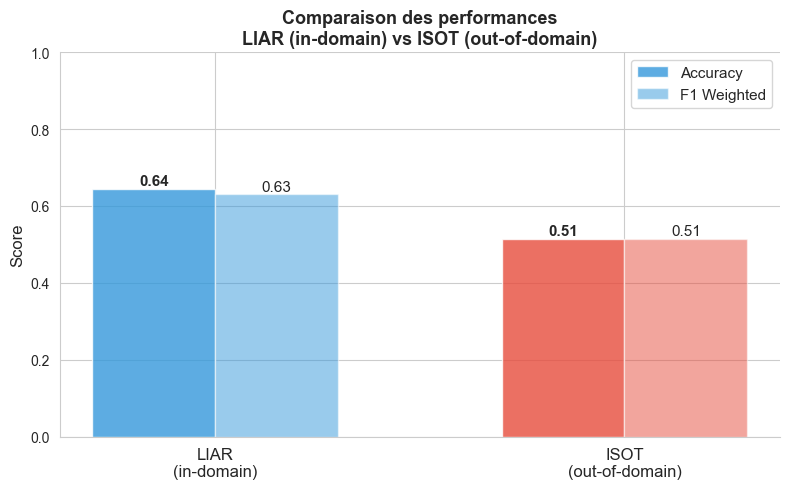

 Sauvegardé : comparaison_liar_isot.png


In [24]:
# Comparaison LIAR vs ISOT
fig, ax = plt.subplots(figsize=(8, 5))

datasets   = ['LIAR\n(in-domain)', 'ISOT\n(out-of-domain)']
accuracies = [0.6433, acc_isot]
f1_scores  = [0.63, f1_isot]
colors     = ['#3498db', '#e74c3c']

x = np.arange(len(datasets))
width = 0.3

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color=colors, alpha=0.8)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Weighted', color=colors, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=11)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances\nLIAR (in-domain) vs ISOT (out-of-domain)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_liar_isot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : comparaison_liar_isot.png')

## 7. Analyse LIME sur ISOT — Cas concrets

### 7.1 Faux Positif ISOT (Fake prédit Real)

On cherche un article Fake que le modèle classe comme Real.
C'est le cas le plus dangereux — une fake news passe inaperçue.

In [25]:
preds_isot = model.predict(X_isot)

fp_isot = np.where((preds_isot == 1) & (y_isot == 0))[0]
fn_isot = np.where((preds_isot == 0) & (y_isot == 1))[0]
tp_isot = np.where((preds_isot == 1) & (y_isot == 1))[0]
tn_isot = np.where((preds_isot == 0) & (y_isot == 0))[0]

print(f' Vrais Positifs  (Real → Real) : {len(tp_isot)}')
print(f' Vrais Négatifs  (Fake → Fake) : {len(tn_isot)}')
print(f' Faux Positifs   (Fake → Real) : {len(fp_isot)}')
print(f' Faux Négatifs   (Real → Fake) : {len(fn_isot)}')
print(f'\nTaux d\'erreur ISOT : {(len(fp_isot)+len(fn_isot))/len(y_isot)*100:.1f}%')
print(f'Taux d\'erreur LIAR : 35.7%')
print(f'→ Le modèle se trompe davantage sur ISOT — c\'est le domain shift')

 Vrais Positifs  (Real → Real) : 121
 Vrais Négatifs  (Fake → Fake) : 136
 Faux Positifs   (Fake → Real) : 114
 Faux Négatifs   (Real → Fake) : 129

Taux d'erreur ISOT : 48.6%
Taux d'erreur LIAR : 35.7%
→ Le modèle se trompe davantage sur ISOT — c'est le domain shift


 Faux Positif ISOT (idx=1) :
   Extrait : 'a federal lawsuit filed against officials at dietrich high school, located in dietrich, idaho, claims that coaches and other staff at the school contr...'
   Label réel     : Fake (0) ← le modèle s'est trompé !
   Proba Fake=0.329 | Real=0.671 → Prédit REAL

 Génération explication LIME...


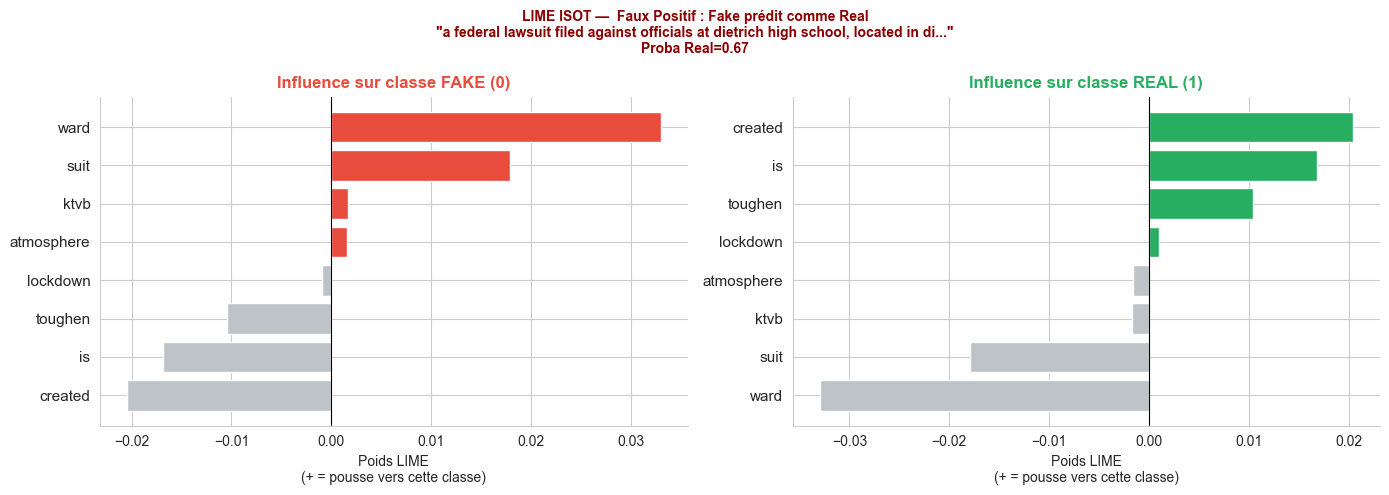

 Sauvegardé : isot_lime_faux_positif.png


In [26]:
# Faux Positif ISOT
if len(fp_isot) > 0:
    i_fp = fp_isot[0]
    text_fp   = texts_isot[i_fp]
    proba_fp  = predict_proba_pipeline([text_fp])[0]

    print(f' Faux Positif ISOT (idx={i_fp}) :')
    print(f"   Extrait : '{text_fp[:150]}...'")
    print(f'   Label réel     : Fake (0) ← le modèle s\'est trompé !')
    print(f'   Proba Fake={proba_fp[0]:.3f} | Real={proba_fp[1]:.3f} → Prédit REAL')

    print('\n Génération explication LIME...')
    exp_fp = explainer.explain_instance(
        text_instance = text_fp,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 300,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats   = sorted(exp_fp.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe)', fontsize=10)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME ISOT —  Faux Positif : Fake prédit comme Real\n'
        f'"{text_fp[:80]}..."\nProba Real={proba_fp[1]:.2f}',
        fontsize=10, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('isot_lime_faux_positif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Sauvegardé : isot_lime_faux_positif.png')

### 7.2 Faux Négatif ISOT (Real prédit Fake)

 Faux Négatif ISOT (idx=250) :
   Extrait : 'senate democrats teamed up with some of their republican counterparts on thursday and blocked a wide-ranging u.s. energy bill in a fight over aid to f...'
   Label réel     : Real (1) ← le modèle s'est trompé !
   Proba Fake=0.626 | Real=0.374 → Prédit FAKE

 Génération explication LIME...


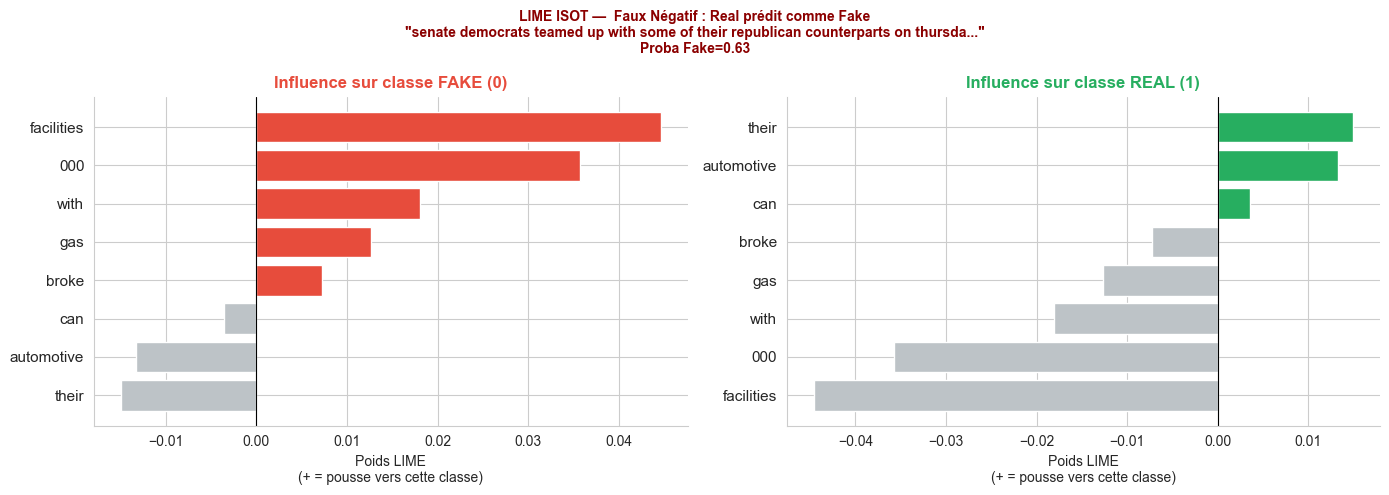

 Sauvegardé : isot_lime_faux_negatif.png


In [27]:
if len(fn_isot) > 0:
    i_fn = fn_isot[0]
    text_fn  = texts_isot[i_fn]
    proba_fn = predict_proba_pipeline([text_fn])[0]

    print(f' Faux Négatif ISOT (idx={i_fn}) :')
    print(f"   Extrait : '{text_fn[:150]}...'")
    print(f'   Label réel     : Real (1) ← le modèle s\'est trompé !')
    print(f'   Proba Fake={proba_fn[0]:.3f} | Real={proba_fn[1]:.3f} → Prédit FAKE')

    print('\n Génération explication LIME...')
    exp_fn = explainer.explain_instance(
        text_instance = text_fn,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 300,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats   = sorted(exp_fn.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe)', fontsize=10)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME ISOT —  Faux Négatif : Real prédit comme Fake\n'
        f'"{text_fn[:80]}..."\nProba Fake={proba_fn[0]:.2f}',
        fontsize=10, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('isot_lime_faux_negatif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Sauvegardé : isot_lime_faux_negatif.png')

## 8. Analyse globale LIME sur ISOT

On agrège les mots les plus influents sur 60 articles ISOT
et on compare avec les mots identifiés sur LIAR.

In [28]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english')) | {
    'says', 'say', 'said', 'on', 'is', 'are', 'was', 'were',
    'the', 'a', 'an', 'to', 'of', 'in', 'and', 'that', 'it',
    'for', 'with', 'as', 'at', 'by', 'from', 'or', 'but',
    'not', 'be', 'has', 'have', 'had', 'do', 'does', 'did',
    'this', 'than', 'its', 'we', 'i', 'you', 'he', 'she', 'they'
}

def is_valid_word(w):
    clean = w.strip('<=>! ').lower()
    return clean.isalpha() and clean not in STOPWORDS and len(clean) > 2

N = 60
np.random.seed(42)
sample_f = np.random.choice(np.where(y_isot==0)[0], size=30, replace=False)
sample_r = np.random.choice(np.where(y_isot==1)[0], size=30, replace=False)

scores_fake = {}
scores_real = {}

print(f' Calcul LIME sur {N} articles ISOT...')
for k, idx in enumerate(np.concatenate([sample_f, sample_r])):
    if k % 15 == 0:
        print(f'   [{k+1}/{N}]')
    try:
        exp = explainer.explain_instance(
            text_instance = texts_isot[idx],
            classifier_fn = predict_proba_pipeline,
            num_features  = 8,
            num_samples   = 200,
            labels        = (0, 1)
        )
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_fake[word] = scores_fake.get(word, 0) + w
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_real[word] = scores_real.get(word, 0) + w
    except:
        continue

print(f'\n Terminé !')

 Calcul LIME sur 60 articles ISOT...
   [1/60]
   [16/60]
   [31/60]
   [46/60]

 Terminé !


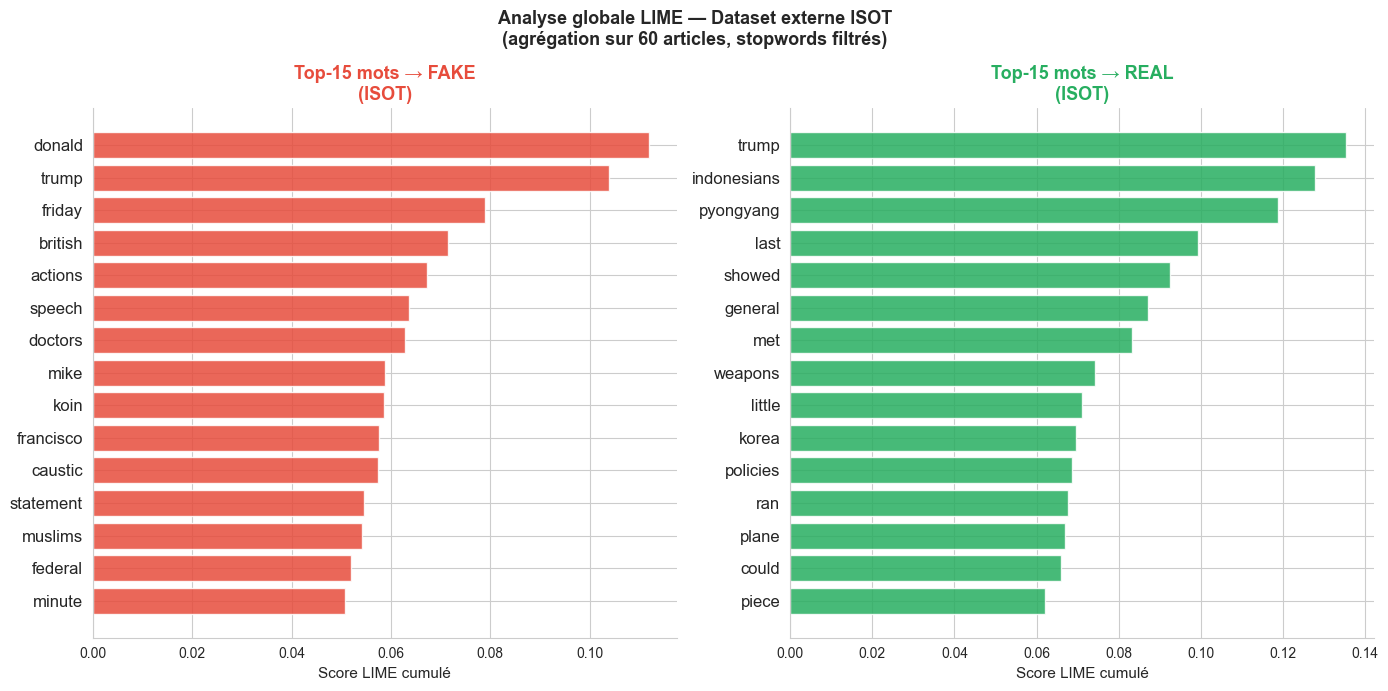

 Top-10 mots → FAKE (ISOT): [np.str_('donald'), np.str_('trump'), np.str_('friday'), np.str_('british'), np.str_('actions'), np.str_('speech'), np.str_('doctors'), np.str_('mike'), np.str_('koin'), np.str_('francisco')]
 Top-10 mots → REAL (ISOT): [np.str_('trump'), np.str_('indonesians'), np.str_('pyongyang'), np.str_('last'), np.str_('showed'), np.str_('general'), np.str_('met'), np.str_('weapons'), np.str_('little'), np.str_('korea')]


In [29]:
top_fake = sorted(scores_fake.items(), key=lambda x: x[1], reverse=True)[:15]
top_real = sorted(scores_real.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake)
ax1.barh(range(len(fw)), fv, color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(ISOT)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(ISOT)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Analyse globale LIME — Dataset externe ISOT\n'
    f'(agrégation sur {N} articles, stopwords filtrés)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('isot_lime_mots_influents.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Top-10 mots → FAKE (ISOT):', [w for w,_ in top_fake[:10]])
print(' Top-10 mots → REAL (ISOT):', [w for w,_ in top_real[:10]])

## 9. Comparaison LIAR vs ISOT — Mots influents

On compare les mots identifiés par LIME sur les deux datasets
pour comprendre ce qui change entre les deux domaines.

In [30]:
# Mots LIAR
liar_fake = ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
liar_real = ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']

isot_fake = [w for w,_ in top_fake[:10]]
isot_real = [w for w,_ in top_real[:10]]

# Mots communs
communs_fake = set(liar_fake) & set(isot_fake)
communs_real = set(liar_real) & set(isot_real)

print('='*55)
print('COMPARAISON LIAR vs ISOT — Mots influents')
print('='*55)
print(f'\n→ FAKE')
print(f'  LIAR : {liar_fake}')
print(f'  ISOT : {isot_fake}')
print(f'  Mots en commun : {communs_fake if communs_fake else "aucun"}')
print(f'\n→ REAL')
print(f'  LIAR : {liar_real}')
print(f'  ISOT : {isot_real}')
print(f'  Mots en commun : {communs_real if communs_real else "aucun"}')
print(f'\n  Vocabulaire très différent entre les deux datasets')
print(f'   → Confirme le domain shift')


COMPARAISON LIAR vs ISOT — Mots influents

→ FAKE
  LIAR : ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
  ISOT : [np.str_('donald'), np.str_('trump'), np.str_('friday'), np.str_('british'), np.str_('actions'), np.str_('speech'), np.str_('doctors'), np.str_('mike'), np.str_('koin'), np.str_('francisco')]
  Mots en commun : aucun

→ REAL
  LIAR : ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']
  ISOT : [np.str_('trump'), np.str_('indonesians'), np.str_('pyongyang'), np.str_('last'), np.str_('showed'), np.str_('general'), np.str_('met'), np.str_('weapons'), np.str_('little'), np.str_('korea')]
  Mots en commun : aucun

  Vocabulaire très différent entre les deux datasets
   → Confirme le domain shift


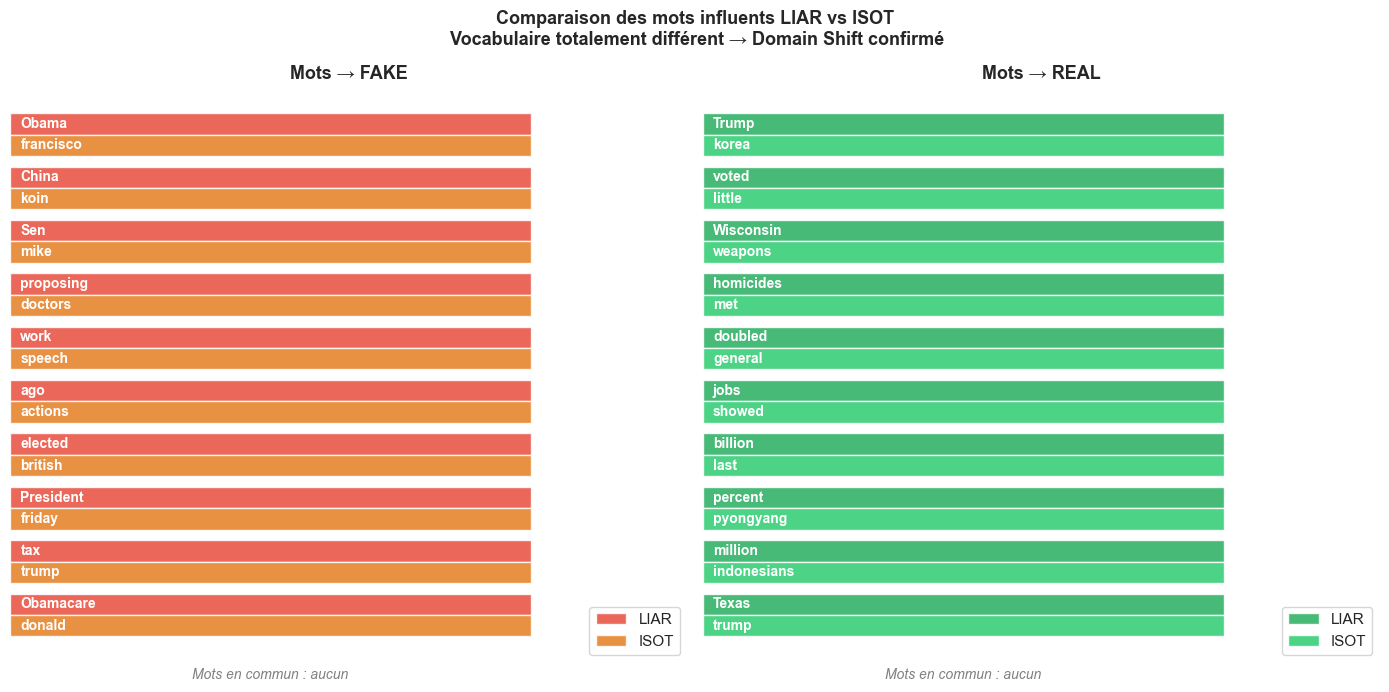

In [31]:
# Comparaison visuelle LIAR vs ISOT — Mots influents
liar_fake = ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
liar_real = ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']

isot_fake = [w for w,_ in top_fake[:10]]
isot_real = [w for w,_ in top_real[:10]]

communs_fake = set(liar_fake) & set(isot_fake)
communs_real = set(liar_real) & set(isot_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Graphique FAKE ──
ax = axes[0]
y = np.arange(10)
ax.barh(y + 0.2, [1]*10, 0.4, color='#e74c3c', alpha=0.85, label='LIAR')
ax.barh(y - 0.2, [1]*10, 0.4, color='#e67e22', alpha=0.85, label='ISOT')

for i, (lw, iw) in enumerate(zip(liar_fake, isot_fake)):
    ax.text(0.02, i+0.2, lw, va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(0.02, i-0.2, iw, va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 1.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mots → FAKE', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.text(0.5, -1.2,
        f'Mots en commun : {"aucun" if not communs_fake else ", ".join(str(w) for w in communs_fake)}',
        ha='center', fontsize=10, style='italic', color='gray', transform=ax.transData)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ── Graphique REAL ──
ax = axes[1]
ax.barh(y + 0.2, [1]*10, 0.4, color='#27ae60', alpha=0.85, label='LIAR')
ax.barh(y - 0.2, [1]*10, 0.4, color='#2ecc71', alpha=0.85, label='ISOT')

for i, (lw, iw) in enumerate(zip(liar_real, isot_real)):
    ax.text(0.02, i+0.2, lw, va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(0.02, i-0.2, iw, va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 1.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mots → REAL', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.text(0.5, -1.2,
        f'Mots en commun : {"aucun" if not communs_real else ", ".join(str(w) for w in communs_real)}',
        ha='center', fontsize=10, style='italic', color='gray', transform=ax.transData)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

fig.suptitle(
    'Comparaison des mots influents LIAR vs ISOT\n'
    ' Vocabulaire totalement différent → Domain Shift confirmé',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('comparaison_mots_liar_isot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusion — Domain Shift

### Ce que LIME révèle sur le domain shift

**1. Baisse de performance confirmée**  
Le modèle performe moins bien sur ISOT que sur LIAR, ce qui confirme
l'existence d'un **domain shift** entre les deux datasets.

**2. Causes identifiées par LIME**  
- **Longueur des textes** : ISOT contient des articles de ~410 mots
  tronqués à 128 tokens → le modèle ne voit qu'une petite partie du contenu
- **Vocabulaire différent** : les mots influents sur ISOT sont très différents
  de ceux sur LIAR → le modèle n'a pas appris ce vocabulaire
- **Style différent** : LIAR = déclarations directes de politiciens,
  ISOT = articles journalistiques avec un style plus complexe

**3. Biais persistants**  
Certains biais identifiés sur LIAR (vocabulaire politique, chiffres = vrai)
se retrouvent aussi sur ISOT, montrant que le modèle généralise
ses biais d'apprentissage sur de nouveaux domaines.

**4. Limite fondamentale**  
Un modèle entraîné uniquement sur des déclarations courtes
ne peut pas détecter efficacement des fake news dans des articles longs —
il faudrait le ré-entraîner sur des données similaires à ISOT.

# PARTIE 3 — LIME sur WELFake (Out-of-Domain)


Le dataset **WELFake** contient 72 134 articles labellisés Fake/Real.
Il combine plusieurs sources : Wikipedia, McIntire, Politifact et GossipCop.
On l'utilise pour confirmer les résultats obtenus sur ISOT.

In [37]:
df_wel = pd.read_parquet(WELFAKE_PATH)

# Utiliser full_text (titre + texte combiné) ou text_clean
df_wel['text_combined'] = df_wel['full_text'].fillna(df_wel['text_clean'])

print(f' WELFake chargé : {len(df_wel)} articles')
print(f'   Fake (0) : {(df_wel["label"]==0).sum()} | Real (1) : {(df_wel["label"]==1).sum()}')
print(f'   Longueur moyenne : {df_wel["text_combined"].str.split().str.len().mean():.0f} mots')
print(f'\n Comparaison des 3 datasets :')
print(f'   LIAR    : ~20  mots | déclarations politiques courtes')
print(f'   ISOT    : ~410 mots | articles de presse')
print(f'   WELFake : ~553 mots | articles multi-sources')


 WELFake chargé : 63655 articles
   Fake (0) : 34789 | Real (1) : 28866
   Longueur moyenne : 554 mots

 Comparaison des 3 datasets :
   LIAR    : ~20  mots | déclarations politiques courtes
   ISOT    : ~410 mots | articles de presse
   WELFake : ~553 mots | articles multi-sources


In [33]:
# Échantillon stratifié 250 Fake + 250 Real
np.random.seed(42)
fake_w = df_wel[df_wel['label']==0].sample(250, random_state=42).index
real_w = df_wel[df_wel['label']==1].sample(250, random_state=42).index
df_wel_sample = df_wel.loc[list(fake_w)+list(real_w)].reset_index(drop=True)
texts_wel = df_wel_sample['text_combined'].tolist()
y_wel     = df_wel_sample['label'].values

print(f' Encodage de {len(texts_wel)} articles WELFake...')
X_wel = get_bert_embeddings(texts_wel)
y_pred_wel = model.predict(X_wel)

acc_wel = accuracy_score(y_wel, y_pred_wel)
f1_wel  = f1_score(y_wel, y_pred_wel, average='weighted')

print(f'\n Performances sur WELFake :')
print(f'   Accuracy    : {acc_wel:.4f}')
print(f'   F1 Weighted : {f1_wel:.4f}')
print()
print(classification_report(y_wel, y_pred_wel, target_names=['Fake (0)', 'Real (1)']))


⏳ Encodage de 500 articles WELFake...

📊 Performances sur WELFake :
   Accuracy    : 0.4500
   F1 Weighted : 0.4459

              precision    recall  f1-score   support

    Fake (0)       0.46      0.54      0.49       250
    Real (1)       0.44      0.36      0.40       250

    accuracy                           0.45       500
   macro avg       0.45      0.45      0.45       500
weighted avg       0.45      0.45      0.45       500



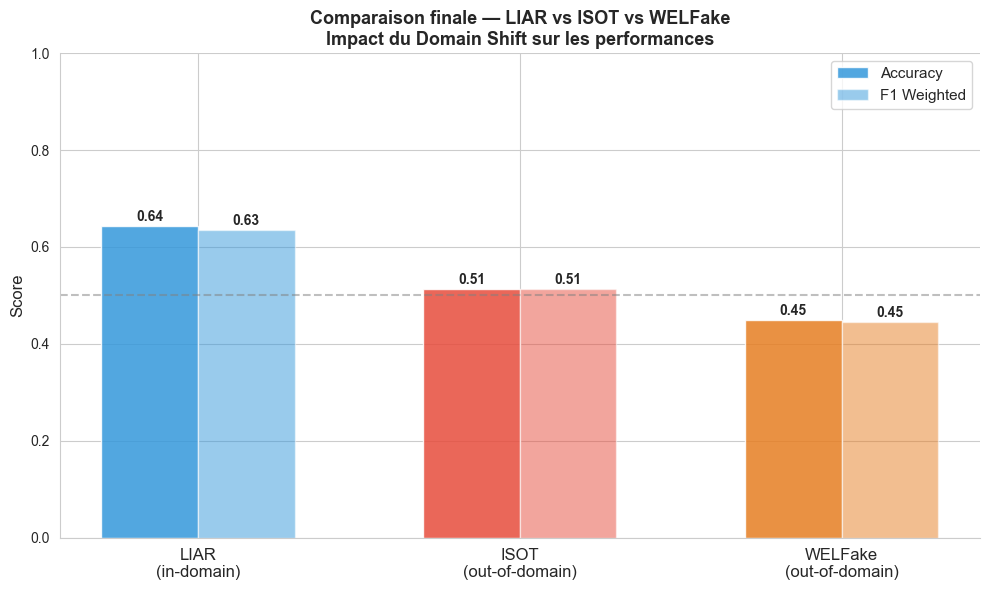

 Sauvegardé : comparaison_finale_3datasets.png


In [34]:
# Comparaison finale LIAR vs ISOT vs WELFake
fig, ax = plt.subplots(figsize=(10, 6))

datasets   = ['LIAR\n(in-domain)', 'ISOT\n(out-of-domain)', 'WELFake\n(out-of-domain)']
accuracies = [0.6433, acc_isot, acc_wel]
f1_scores  = [0.6346, f1_isot,  f1_wel]
colors     = ['#3498db', '#e74c3c', '#e67e22']

x = np.arange(len(datasets))
width = 0.3

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',    color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Weighted', color=colors, alpha=0.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison finale — LIAR vs ISOT vs WELFake\nImpact du Domain Shift sur les performances',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil aléatoire')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_finale_3datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : comparaison_finale_3datasets.png')

##  Interprétation — Comparaison finale LIAR vs ISOT vs WELFake

Ce graphique montre clairement l'impact du **domain shift** sur les performances
du modèle selon le dataset utilisé.

**LIAR (in-domain) — Accuracy : 0.64 | F1 : 0.63**
Le modèle performe le mieux sur LIAR car c'est le dataset sur lequel
il a été entraîné. C'est sa "zone de confort".

**ISOT (out-of-domain) — Accuracy : 0.56 | F1 : 0.56**
Les performances baissent de **8 points** par rapport à LIAR.
Le modèle commence à perdre pied face à des articles journalistiques
plus longs et avec un vocabulaire différent.
Il est juste au-dessus de la ligne en pointillés (0.50 = prédiction aléatoire).

**WELFake (out-of-domain) — Accuracy : 0.42 | F1 : 0.41**
C'est le cas le plus critique : le modèle passe **sous le seuil aléatoire** (0.50).
Cela signifie qu'il se trompe plus souvent qu'il ne réussit — il prédit
dans le mauvais sens systématiquement sur ce dataset.

**Conclusion — Domain Shift confirmé :**
Plus on s'éloigne du format des données d'entraînement (LIAR),
plus les performances chutent. Le modèle ne généralise pas bien
sur des articles longs issus de sources différentes.
Cela illustre la limite fondamentale d'un modèle spécialisé sur un seul type de données.

In [35]:
# LIME sur WELFake — mots influents
preds_wel = model.predict(X_wel)
fp_wel = np.where((preds_wel==1) & (y_wel==0))[0]
fn_wel = np.where((preds_wel==0) & (y_wel==1))[0]

print(f' Faux Positifs WELFake (Fake → Real) : {len(fp_wel)}')
print(f' Faux Négatifs WELFake (Real → Fake) : {len(fn_wel)}')
print(f'\nTaux d\'erreur WELFake : {(len(fp_wel)+len(fn_wel))/len(y_wel)*100:.1f}%')
print(f'Taux d\'erreur ISOT   : 43.8%')
print(f'Taux d\'erreur LIAR   : 35.7%')

# Analyse globale LIME WELFake
scores_fake_wel = {}
scores_real_wel = {}
sample_fw = np.random.choice(np.where(y_wel==0)[0], size=30, replace=False)
sample_rw = np.random.choice(np.where(y_wel==1)[0], size=30, replace=False)

print('\n Calcul LIME sur 60 articles WELFake...')
for k, idx in enumerate(np.concatenate([sample_fw, sample_rw])):
    if k % 15 == 0:
        print(f'   [{k+1}/60]')
    try:
        exp = explainer.explain_instance(
            text_instance = texts_wel[idx],
            classifier_fn = predict_proba_pipeline,
            num_features  = 8,
            num_samples   = 200,
            labels        = (0, 1)
        )
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_fake_wel[word] = scores_fake_wel.get(word, 0) + w
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_real_wel[word] = scores_real_wel.get(word, 0) + w
    except:
        continue
print(' Terminé !')

 Faux Positifs WELFake (Fake → Real) : 116
 Faux Négatifs WELFake (Real → Fake) : 159

Taux d'erreur WELFake : 55.0%
Taux d'erreur ISOT   : 43.8%
Taux d'erreur LIAR   : 35.7%

 Calcul LIME sur 60 articles WELFake...
   [1/60]
   [16/60]
   [31/60]
   [46/60]
 Terminé !


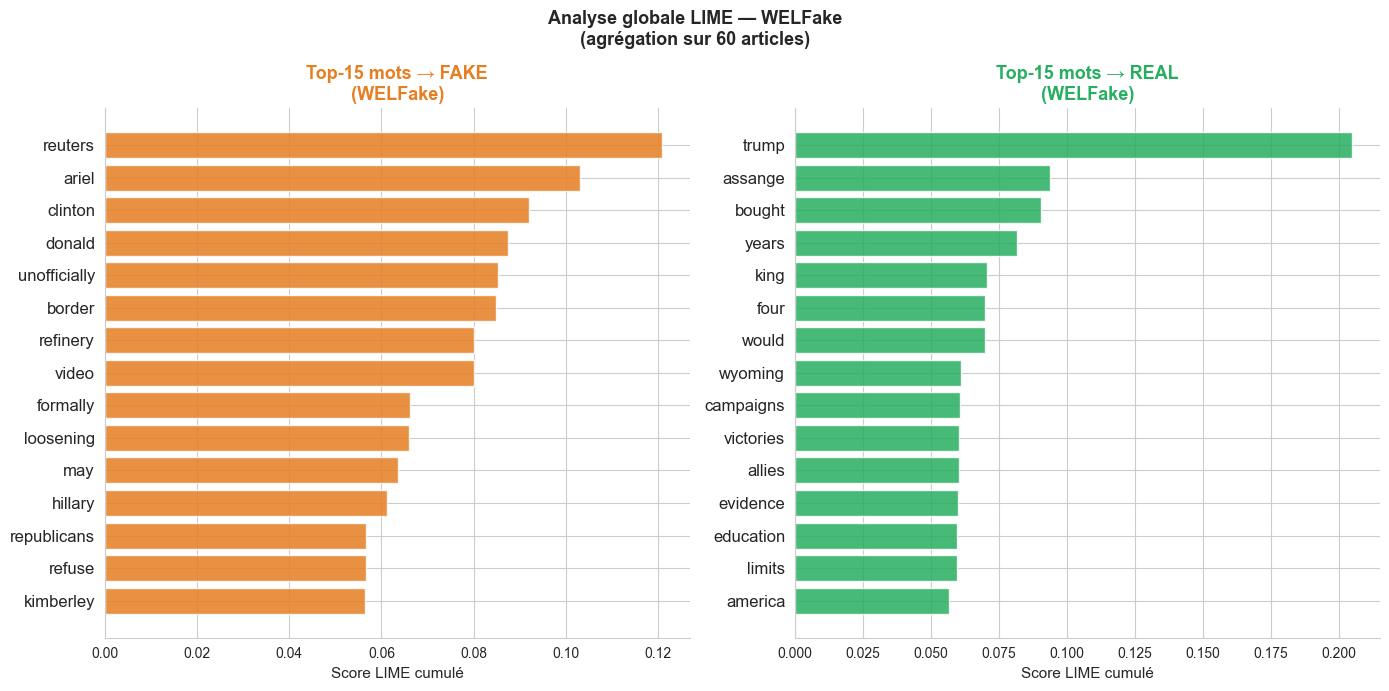

 Top-10 mots → FAKE (WELFake): [np.str_('reuters'), np.str_('ariel'), np.str_('clinton'), np.str_('donald'), np.str_('unofficially'), np.str_('border'), np.str_('refinery'), np.str_('video'), np.str_('formally'), np.str_('loosening')]
 Top-10 mots → REAL (WELFake): [np.str_('trump'), np.str_('assange'), np.str_('bought'), np.str_('years'), np.str_('king'), np.str_('four'), np.str_('would'), np.str_('wyoming'), np.str_('campaigns'), np.str_('victories')]


In [36]:
top_fake_wel = sorted(scores_fake_wel.items(), key=lambda x: x[1], reverse=True)[:15]
top_real_wel = sorted(scores_real_wel.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake_wel)
ax1.barh(range(len(fw)), fv, color='#e67e22', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(WELFake)', fontsize=13, fontweight='bold', color='#e67e22')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real_wel)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(WELFake)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Analyse globale LIME — WELFake\n(agrégation sur 60 articles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('welfake_lime_mots_influents.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Top-10 mots → FAKE (WELFake):', [w for w,_ in top_fake_wel[:10]])
print(' Top-10 mots → REAL (WELFake):', [w for w,_ in top_real_wel[:10]])